#  컬러 이미지 모델링

* 본 파일은 GPU 런타임으로 연결됩니다.
* 경우에 따라서는 GPU 연결이 원활하지 않을 수도 있습니다.

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.datasets import cifar10

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err')
    plt.plot(history['val_loss'], label='val_err')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

![fashion class](https://datasets.activeloop.ai/wp-content/uploads/2022/09/CIFAR-10-dataset-Activeloop-Platform-visualization-image-1.webp)

In [3]:
# cifar10 데이터셋 불러오기
(x_train, y_train), (x_val, y_val) = cifar10.load_data()

170498071/170498071 [==============================] - 16s 0us/step


In [4]:
x_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 2 데이터 살펴보기

In [6]:
y_train[1].item()

9

truck


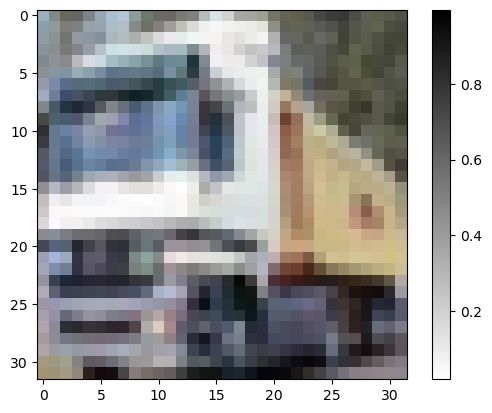

In [17]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1

print(class_names[y_train[n].item()])
plt.figure()
plt.imshow(x_train[n], cmap=plt.cm.binary)
plt.colorbar()
plt.show()

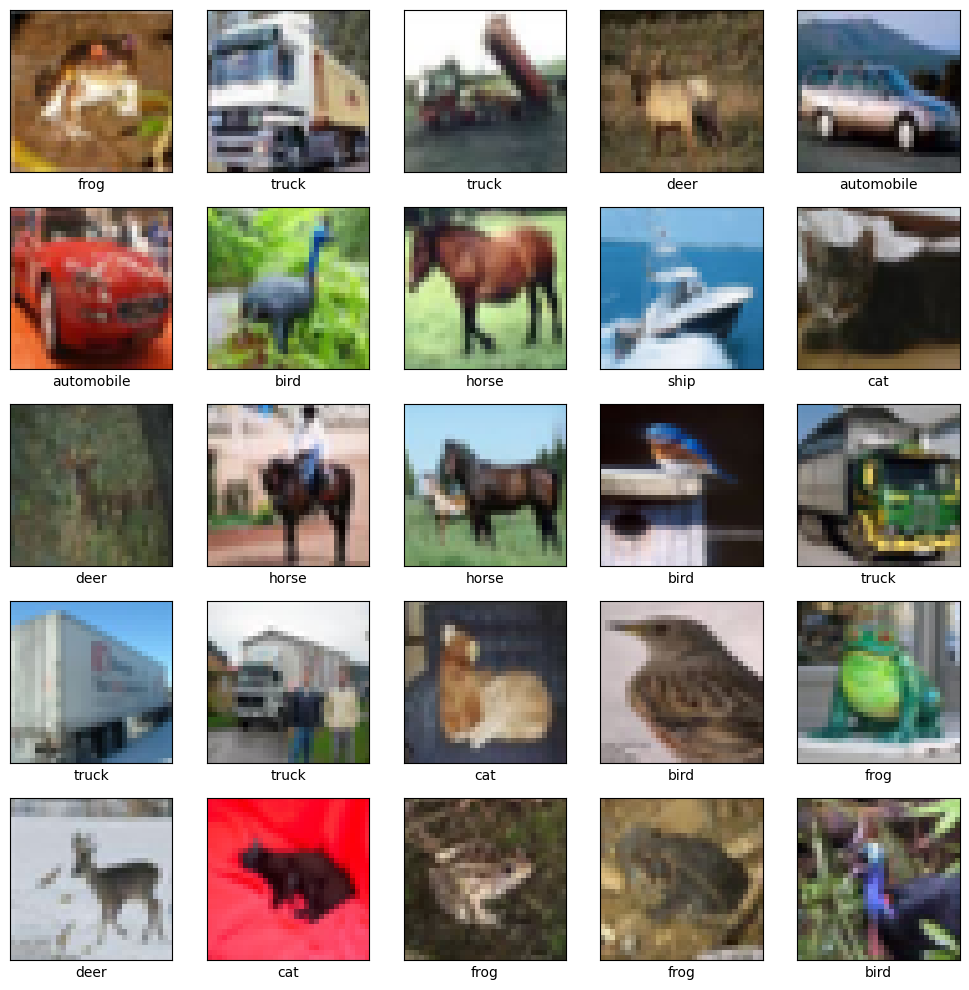

In [8]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i].item()])
plt.tight_layout()
plt.show()

## 3.데이터 준비

* CNN은 3차원 구조의 이미지(데이터셋은 4차원)를 입력해야 합니다.(input_shape)

In [9]:
x_train.shape, x_val.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

* Scaling : Min-Max
    * 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
    * x_train, x_val를 그냥 255로 나누면 됨

In [10]:
x_train = x_train / 255.
x_test = x_val / 255.

## 4.CNN 모델링

* 아래 그림의 구조대로 모델을 설계하고 학습해 봅시다.
* learning_rate = 0.0001

In [11]:
clear_session()

model = Sequential([Input(shape = (32, 32, 3)),
                    Conv2D(32, kernel_size=3, padding='same', activation ='relu'), # strides = 1 기본값
                    MaxPooling2D(pool_size = 2),  # strides = pool_size 기본값
                    Conv2D(64, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Flatten(),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 128)               5

In [12]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

history = model.fit(x_train, y_train, epochs = 20,
                    validation_split=0.2).history

Epoch 1/20
1250/1250 [==============================] - 14s 6ms/step - loss: 1.7068 - val_loss: 1.5137
Epoch 2/20
1250/1250 [==============================] - 6s 5ms/step - loss: 1.4159 - val_loss: 1.3611
Epoch 3/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.2783 - val_loss: 1.2470
Epoch 4/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.1902 - val_loss: 1.1722
Epoch 5/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.1257 - val_loss: 1.1428
Epoch 6/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.0765 - val_loss: 1.1310
Epoch 7/20
1250/1250 [==============================] - 6s 5ms/step - loss: 1.0316 - val_loss: 1.0759
Epoch 8/20
1250/1250 [==============================] - 7s 5ms/step - loss: 0.9955 - val_loss: 1.0529
Epoch 9/20
1250/1250 [==============================] - 6s 5ms/step - loss: 0.9640 - val_loss: 1.0733
Epoch 10/20
1250/1250 [==============================] - 7s 5ms/step - loss: 0.93

* 학습결과 그래프

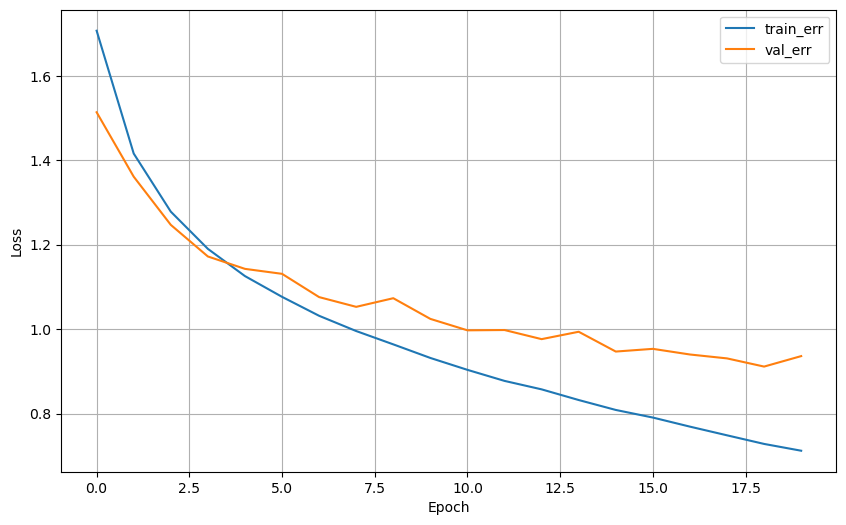

In [ ]:
dl_history_plot(history)

* 예측 및 평가

In [14]:
pred = model.predict(x_val)

313/313 [==============================] - 1s 2ms/step


In [15]:
pred_1 = pred.argmax(axis=1)

In [ ]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.5664
------------------------------------------------------------
[[833  18   2   5   3   1   0   5  41  92]
 [ 45 715   0   1   0   1   1   1  15 221]
 [260  17 202  75  58  74  30 109  40 135]
 [120  22  17 344  35 106  20  73  54 209]
 [174  13  15  65 342  33  16 190  29 123]
 [ 73  10  15 135  23 446   8 140  28 122]
 [ 79  43  18  77  21  30 483  23  41 185]
 [ 68   8   6  12  13  27   1 724  12 129]
 [150  35   0   3   1   2   0   3 714  92]
 [ 44  66   1   2   0   1   0   4  21 861]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.45      0.83      0.59      1000
           1       0.76      0.71      0.73      1000
           2       0.73      0.20      0.32      1000
           3       0.48      0.34      0.40      1000
           4       0.69      0.34      0.46      1000
           5       0.62      0.45      0.52      1000
           6       0.86      0.48      0.62      1000
       

## 5.실습 : 성능을 더 높이기 위한 모델링

In [44]:
clear_session()

model = Sequential([Input(shape = (32, 32, 3)),
                    Conv2D(32, kernel_size=3, padding='same', activation ='relu'), # strides = 1 기본값
                    MaxPooling2D(pool_size = 2),  # strides = pool_size 기본값
                    Conv2D(64, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Conv2D(128, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Flatten(),
                    Dense(512, activation = 'relu'),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
])

model.summary()
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 4, 4, 128)        0

In [45]:
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1
).history

Epoch 1/20
782/782 [==============================] - 5s 5ms/step - loss: 1.4499 - accuracy: 0.4695 - val_loss: 139.5406 - val_accuracy: 0.4794
Epoch 2/20
782/782 [==============================] - 4s 5ms/step - loss: 0.9930 - accuracy: 0.6486 - val_loss: 128.4571 - val_accuracy: 0.5417
Epoch 3/20
782/782 [==============================] - 4s 5ms/step - loss: 0.7961 - accuracy: 0.7216 - val_loss: 131.7635 - val_accuracy: 0.5589
Epoch 4/20
782/782 [==============================] - 4s 5ms/step - loss: 0.6686 - accuracy: 0.7655 - val_loss: 126.4204 - val_accuracy: 0.5705
Epoch 5/20
782/782 [==============================] - 4s 5ms/step - loss: 0.5594 - accuracy: 0.8026 - val_loss: 143.6660 - val_accuracy: 0.5826
Epoch 6/20
782/782 [==============================] - 4s 5ms/step - loss: 0.4682 - accuracy: 0.8351 - val_loss: 161.7463 - val_accuracy: 0.5791
Epoch 7/20
782/782 [==============================] - 4s 5ms/step - loss: 0.3748 - accuracy: 0.8691 - val_loss: 209.2186 - val_accuracy:

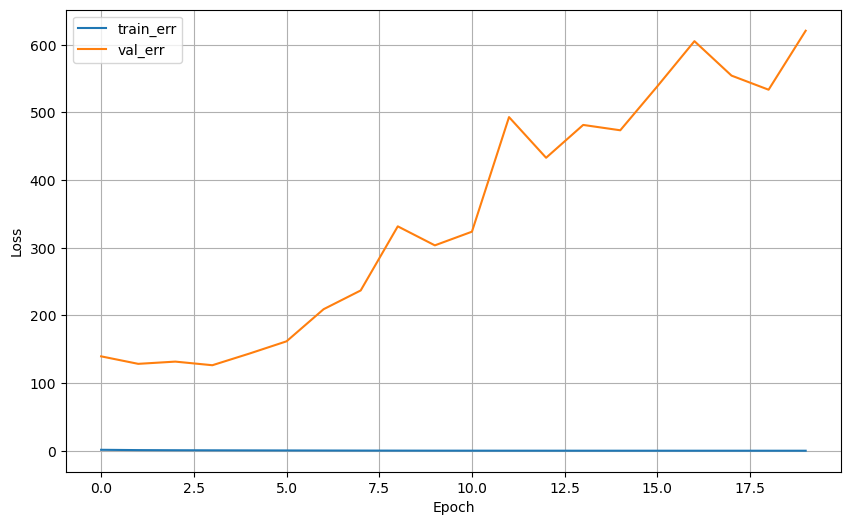

In [46]:
dl_history_plot(history)

In [47]:
pred = model.predict(x_val)
pred_1 = pred.argmax(axis=1)

313/313 [==============================] - 1s 2ms/step


In [48]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.546
------------------------------------------------------------
[[842  36   8  31   1   3   1  10  39  29]
 [ 42 831   0   3   0   3   1   3  39  78]
 [199  52 253 166   4 134  20  68  40  64]
 [ 79  39  25 450   7 168  15  63  47 107]
 [135  50  37 222  78 162  30 158  32  96]
 [ 45  23   8 197   1 526   4  87  33  76]
 [ 69  58  17 175   3 123 391  32  65  67]
 [ 47  22   9  69   3  58   1 675  15 101]
 [207  54   3   9   0   1   0   6 666  54]
 [ 78 144   0   5   0   1   0   9  15 748]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.48      0.84      0.61      1000
           1       0.63      0.83      0.72      1000
           2       0.70      0.25      0.37      1000
           3       0.34      0.45      0.39      1000
           4       0.80      0.08      0.14      1000
           5       0.45      0.53      0.48      1000
           6       0.84      0.39      0.53      1000
        